In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf

GENERATED_DIR = Path.cwd() / "generated"

Matplotlib created a temporary config/cache directory at /tmp/matplotlib-n2kgiz5b because the default path (/.config/matplotlib) is not a writable directory; it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


In [2]:
ACOUSTIC_DIR = GENERATED_DIR / "acoustic"
LINGUISTIC_DIR = GENERATED_DIR / "linguistic_frame"

In [3]:
DATA_SIZE = 4000

acoustic_paths = sorted(ACOUSTIC_DIR.glob("*"))[:DATA_SIZE] # Remove mean.npy and std.npy
linguistic_paths = sorted(LINGUISTIC_DIR.glob("*"))[:DATA_SIZE]
len(acoustic_paths), len(linguistic_paths)

(4000, 4000)

In [4]:
acoustic_arrays = [np.load(path) for path in acoustic_paths]
linguistic_arrays = [np.load(path) for path in linguistic_paths]

In [5]:
# Truncate, same length
acoustic_arrays = [ac_arr[:len(ln_arr)] for ac_arr, ln_arr in zip(acoustic_arrays, linguistic_arrays)]

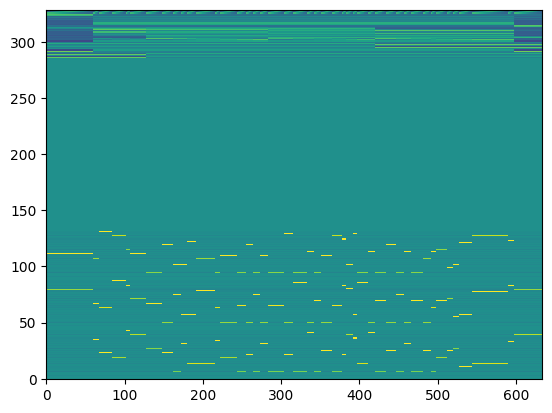

In [6]:
plt.imshow(linguistic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [7]:
linguistic_arrays[0].shape

(634, 329)

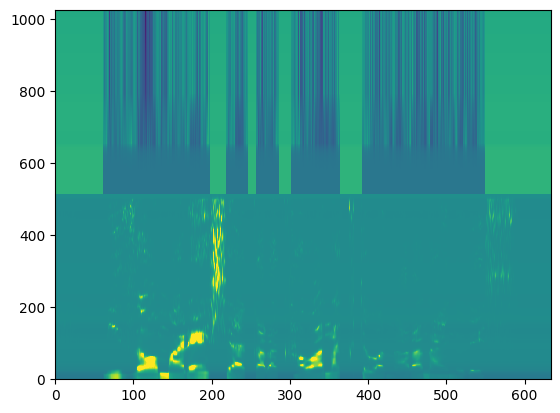

In [8]:
plt.imshow(acoustic_arrays[0].T, origin='lower', aspect='auto', interpolation='nearest')
plt.clim(-4, +4)

In [9]:
f0_arrays = [arr[:, 0:0 + 1] for arr in acoustic_arrays]
sp_arrays = [arr[:, 1:1 + 513] for arr in acoustic_arrays]
ap_arrays = [arr[:, 1 + 513: 1 + 513 + 513] for arr in acoustic_arrays]

In [10]:
def data_gen():
    for lng, f0, sp, ap in zip(linguistic_arrays, f0_arrays, sp_arrays, ap_arrays):
        yield lng, (f0, sp, ap)

In [66]:
def lng_gen():
    for lng in linguistic_arrays:
        yield lng

def f0_gen():
    for arr in acoustic_arrays:
        yield arr[:, 0:1]

def sp_gen():
    for arr in acoustic_arrays:
        yield arr[:, 1:1 + 513]

def ap_gen():
    for arr in acoustic_arrays:
        yield arr[:, 1 + 513: 1 + 513 + 513]
        
lng_ds = tf.data.Dataset.from_generator(lng_gen, output_types=tf.float32, output_shapes=(None, 329)).flat_map(tf.data.Dataset.from_tensor_slices)
f0_ds = tf.data.Dataset.from_generator(f0_gen, output_types=tf.float32, output_shapes=(None, 1)).flat_map(tf.data.Dataset.from_tensor_slices)
sp_ds = tf.data.Dataset.from_generator(sp_gen, output_types=tf.float32, output_shapes=(None, 513)).flat_map(tf.data.Dataset.from_tensor_slices)
ap_ds = tf.data.Dataset.from_generator(ap_gen, output_types=tf.float32, output_shapes=(None, 513)).flat_map(tf.data.Dataset.from_tensor_slices)
y_ds = tf.data.Dataset.zip((f0_ds, sp_ds, ap_ds))

In [59]:
dataset = tf.

AttributeError: 'tuple' object has no attribute 'isidentifier'

In [ ]:
from tensorflow.keras.layers import *

def _extend(ipt, name):
    
    resid_feature = Reshape((1, -1))(Dense(32, activation='relu', name=f'{name}_res_f')(ipt))
    resid_space = Reshape((-1, 1))(Dense(16, activation='relu', name=f'{name}_res_s')(ipt))
    
    x = Reshape((1, -1))(ipt)
    x = Conv1DTranspose(128, 7, strides=4, padding='same', name=f'{name}_c_1')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(32, 7, strides=4, padding='same')(x)
    x = Add(name=f'{name}_add')([x, resid_feature, resid_space])
    x = ReLU()(x)
    x = Conv1DTranspose(8, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(2, 7, strides=4, padding='same')(x)
    x = ReLU()(x)
    x = Conv1DTranspose(1, 3, strides=2, padding='same')(x)
    x = Flatten()(x)
    last = Dense(1)(x)
    x = Concatenate(name=f'{name}_out')([x, last])
    return x


def get_model(input_dim = 329, f0_dim=1, sp_dim=513, ap_dim=513):
    ipt = tf.keras.layers.Input(shape=(input_dim,))
    x = tf.keras.layers.Dense(256,)(ipt)
    x = tf.keras.layers.ReLU()(x)
    x = tf.keras.layers.Dense(256,)(x)
    x = tf.keras.layers.ReLU()(x)
    
    sp_out = _extend(x, 'sp')
    ap_out = _extend(x, 'ap')
    
    x = tf.keras.layers.Dense(64,)(x)
    x = tf.keras.layers.ReLU()(x)

    f0_out = tf.keras.layers.Dense(1, name="f0")(x)

    model = tf.keras.models.Model(inputs=ipt, outputs=(f0_out, sp_out, ap_out))
    return model

model = get_model()
model.summary()

In [ ]:
from tensorflow.keras.losses import MeanSquaredError as MSE

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=(MSE(), MSE(), MSE()),
              metrics=['MAE'])

In [ ]:
model.fit(dataset, epochs=1000)

20/20 [==============================] - 0s 3ms/step


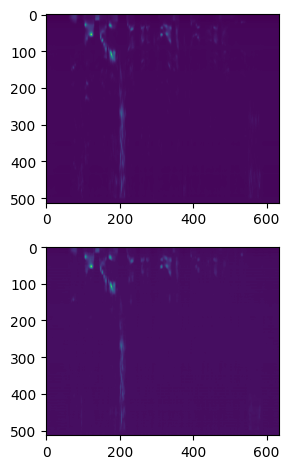

In [50]:
import librosa.display

idx = 0

fig, ax = plt.subplots(2, 1)
ax[0].imshow(sp_arrays[idx].T)
ax[1].imshow(model.predict(linguistic_arrays[idx])[1].T)

plt.tight_layout()

In [51]:
f0, sp, ap = model.predict(linguistic_arrays[idx])

20/20 [==============================] - 0s 2ms/step


In [52]:
mean = np.load("generated/acoustic/mean.npy")
std = np.load("generated/acoustic/std.npy")

def to_audio(f0, sp, ap):
    f0_mean, sp_mean, ap_mean = mean[0:1], mean[1:1+513], mean[1+513:]
    f0_std, sp_std, ap_std = std[0:1], std[1:1+513], std[1+513:]
    f0 = f0_mean + f0_std * f0
    sp = sp_mean + sp_std * sp
    ap = ap_mean + ap_std * ap
    audio = pw.synthesize(f0[:, 0].astype("double"), sp.astype("double"), ap.astype("double"), 22050)
    return audio

In [53]:
import pyworld as pw
import IPython

audio = to_audio(f0, sp, ap)
IPython.display.Audio(audio, rate=22050)

In [54]:
import pyworld as pw
import IPython

audio = to_audio(f0_arrays[idx], sp_arrays[idx], ap_arrays[idx])
IPython.display.Audio(audio, rate=22050)